In [1]:
# ============================================================
# SETUP
# ============================================================
get_ipython().system('pip install earthengine-api geemap -q')
 
import ee
ee.Authenticate()
ee.Initialize(project='osmgee')
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import itertools
import re
from datetime import datetime
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
 
 
# ============================================================
# REMA-KALENGA: PLANET IMAGE + UDM2 MASK PAIRING
# ============================================================
asset_folder_rema = 'projects/annual-ccdc-new/assets/REMA_ONLY_PlanetImages'
 
assets_info_rema = ee.data.listAssets({'parent': asset_folder_rema})
asset_ids_rema = [a['id'] for a in assets_info_rema['assets']]
 
rema_pairs = {}
for asset_id in asset_ids_rema:
    name = asset_id.split('/')[-1]
    match = re.match(r'(\d{8}_\d{6}_\d+_[\da-zA-Z]+)', name)
    if not match:
        print(f'WARNING: could not parse prefix from {name}')
        continue
    prefix = match.group(1)
 
    if 'AnalyticMS_SR' in name:
        rema_pairs.setdefault(prefix, {})['image'] = asset_id
    elif 'udm2' in name:
        rema_pairs.setdefault(prefix, {})['udm'] = asset_id
 
incomplete = {k: v for k, v in rema_pairs.items() if 'image' not in v or 'udm' not in v}
if incomplete:
    print('WARNING: incomplete pairs found:', incomplete)
else:
    print(f'All {len(rema_pairs)} scenes have matched image+mask pairs.')
 
for prefix in rema_pairs:
    date_str = prefix[:8]
    rema_pairs[prefix]['date'] = datetime.strptime(date_str, '%Y%m%d').strftime('%Y-%m-%d')
 
for prefix, info in sorted(rema_pairs.items()):
    print(info['date'], '->', prefix)
 

All 20 scenes have matched image+mask pairs.
2021-01-07 -> 20210107_043441_12_2407
2021-01-07 -> 20210107_043443_39_2407
2021-01-31 -> 20210131_043531_17_2403
2021-01-31 -> 20210131_043533_46_2403
2021-01-31 -> 20210131_043535_75_2403
2021-02-12 -> 20210212_043349_52_2401
2021-02-12 -> 20210212_043351_79_2401
2021-02-12 -> 20210212_043354_06_2401
2021-02-22 -> 20210222_043514_36_2416
2021-02-22 -> 20210222_043516_72_2416
2021-03-04 -> 20210304_043333_93_2413
2021-03-04 -> 20210304_043336_19_2413
2021-03-04 -> 20210304_043338_46_2413
2021-03-17 -> 20210317_034258_42_2206
2021-03-17 -> 20210317_034300_63_2206
2021-03-25 -> 20210325_034756_62_225a
2021-03-25 -> 20210325_034758_90_225a
2021-03-25 -> 20210325_034801_18_225a
2021-03-25 -> 20210325_043553_13_2407
2021-03-25 -> 20210325_043555_40_2407


In [2]:
# ============================================================
# CLOUD/SHADOW MASKING (UDM2: band 3 = shadow, band 6 = cloud, 0 = clear)
# ============================================================
def mask_planet_clouds_shadows(analytic_image, udm_image):
    cloud_mask = udm_image.select('b6').eq(0)
    shadow_mask = udm_image.select('b3').eq(0)
    clear_mask = cloud_mask.And(shadow_mask)
    return analytic_image.updateMask(clear_mask)
 
 
rema_masked_images = []
for prefix, info in rema_pairs.items():
    analytic_img = ee.Image(info['image'])
    udm_img = ee.Image(info['udm'])
 
    masked = mask_planet_clouds_shadows(analytic_img, udm_img)
    masked = masked.set('system:time_start', ee.Date(info['date']).millis())
    masked = masked.set('scene_id', prefix)
 
    rema_masked_images.append(masked)
 
print(f'Built {len(rema_masked_images)} masked images')
 
rema_planet_collection = ee.ImageCollection.fromImages(rema_masked_images)
print('Rema-Kalenga Planet collection size:', rema_planet_collection.size().getInfo())

Built 20 masked images
Rema-Kalenga Planet collection size: 20


In [3]:
# ============================================================
# BOUNDARIES
# ============================================================
rema_boundary = ee.FeatureCollection('projects/osmgee/assets/RemaKalenga')
knp_boundary = ee.FeatureCollection('projects/osmgee/assets/KNP')
 
 
# ============================================================
# REMA-KALENGA: COMPOSITE, SCALING, BAND RENAME
# ============================================================
rema_planet_composite = rema_planet_collection.median().clip(rema_boundary)
 
planet_band_names = ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir']
rema_planet_composite = rema_planet_composite.rename(planet_band_names)
 
print('Bands in Rema-Kalenga Planet composite:', rema_planet_composite.bandNames().getInfo())
 
rema_planet_composite_scaled = rema_planet_composite.divide(10000)
 
scaled_stats = rema_planet_composite_scaled.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=rema_boundary.geometry(),
    scale=30,
    maxPixels=1e9,
    bestEffort=True
)
print('Scaled value ranges per band (Rema-Kalenga):')
print(scaled_stats.getInfo())

Bands in Rema-Kalenga Planet composite: ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir']
Scaled value ranges per band (Rema-Kalenga):
{'blue_max': 0.0752, 'blue_min': 0.0246, 'coastal_blue_max': 0.0616, 'coastal_blue_min': 0.0193, 'green_i_max': 0.1116, 'green_i_min': 0.0429, 'green_max': 0.1061, 'green_min': 0.0333, 'nir_max': 0.3416, 'nir_min': 0.0996, 'red_edge_max': 0.158, 'red_edge_min': 0.0549, 'red_max': 0.1298, 'red_min': 0.0233, 'yellow_max': 0.1489, 'yellow_min': 0.0459}


In [4]:
# ============================================================
# SPECTRAL INDICES (Planet bands; GNDVI uses 'green', matched to Sentinel-2 pipeline)
# ============================================================
def add_indices_planet(image):
    ndvi = image.normalizedDifference(['nir', 'red']).rename('NDVI')
    gndvi = image.normalizedDifference(['nir', 'green']).rename('GNDVI')
 
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('nir'),
            'RED': image.select('red'),
            'BLUE': image.select('blue')
        }).rename('EVI')
 
    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
            'NIR': image.select('nir'),
            'RED': image.select('red')
        }).rename('SAVI')
 
    msavi = image.expression(
        '(2 * NIR + 1 - sqrt((2 * NIR + 1)**2 - 8 * (NIR - RED))) / 2', {
            'NIR': image.select('nir'),
            'RED': image.select('red')
        }).rename('MSAVI')
 
    return image.addBands([ndvi, gndvi, evi, savi, msavi])
 
 
rema_planet_with_indices = add_indices_planet(rema_planet_composite_scaled)
 
planet_raw_bands = ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir']
index_bands = ['NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']
 
final_image_rema_planet = rema_planet_with_indices.select(planet_raw_bands + index_bands)
print('Bands in final Rema-Kalenga Planet image:', final_image_rema_planet.bandNames().getInfo())
 

Bands in final Rema-Kalenga Planet image: ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir', 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']


In [5]:
# ============================================================
# REMA-KALENGA SITES: CLEAN + 15m x 15m SQUARE PLOTS
# ============================================================
rema_sites = ee.FeatureCollection('projects/osmgee/assets/RemaSites')
 
def clean_feature_rema(f):
    lon = ee.Number(f.get('XCoord'))
    lat = ee.Number(f.get('YCoord'))
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')
 
    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )
 
rema_sites_clean = rema_sites.map(clean_feature_rema)
print('Cleaned feature count (Rema-Kalenga):', rema_sites_clean.size().getInfo())
 
 
def make_square_plot(feature):
    point = feature.geometry()
    half_side = 7.5
    square = point.buffer(half_side, 1).bounds()
    return feature.setGeometry(square)
 
rema_sites_squares = rema_sites_clean.map(make_square_plot)
print('Sample square geometry (Rema-Kalenga):', rema_sites_squares.first().geometry().getInfo())

Cleaned feature count (Rema-Kalenga): 59
Sample square geometry (Rema-Kalenga): {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[91.6245064407107, 24.112283907026445], [91.62465051076359, 24.112283907026445], [91.62465051076359, 24.112417491494657], [91.6245064407107, 24.112417491494657], [91.6245064407107, 24.112283907026445]]]}


In [6]:
# ============================================================
# EXTRACT PLANET FEATURES AT REMA-KALENGA PLOTS (scale=3, Planet native resolution)
# ============================================================
rema_planet_extracted = final_image_rema_planet.reduceRegions(
    collection=rema_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=3
)
 
rema_planet_extracted_info = rema_planet_extracted.getInfo()
 
rema_planet_rows = [f['properties'] for f in rema_planet_extracted_info['features']]
df_rema = pd.DataFrame(rema_planet_rows)
 
id_cols = ['cluster_id', 'par_lai', 'longitude', 'latitude']
other_cols = [c for c in df_rema.columns if c not in id_cols]
df_rema = df_rema[id_cols + other_cols]
 
print(f'Extracted {len(df_rema)} plots from Rema-Kalenga Planet imagery')
df_rema
 
 

Extracted 59 plots from Rema-Kalenga Planet imagery


,cluster_id,par_lai,longitude,latitude,EVI,GNDVI,MSAVI,NDVI,SAVI,blue,coastal_blue,green,green_i,nir,red,red_edge,yellow
0,5,0.331170,91.624580,24.112350,0.389005,0.678851,0.341912,0.713837,0.373010,0.030947,0.024310,0.043817,0.052649,0.229073,0.038259,0.074659,0.063881
1,27,3.944147,91.630600,24.165805,0.389212,0.683922,0.338858,0.738222,0.371483,0.029419,0.024980,0.041178,0.047934,0.219397,0.033047,0.068276,0.052358
2,35,2.494383,91.643603,24.170542,0.427655,0.701676,0.378806,0.757648,0.405113,0.029053,0.027350,0.042667,0.050808,0.243417,0.033549,0.074569,0.054202
3,51,3.001718,91.625308,24.203328,0.351603,0.637710,0.304154,0.661268,0.338413,0.034735,0.025975,0.047554,0.055366,0.215128,0.043862,0.078823,0.066772
4,3,2.859987,91.632832,24.109208,0.420541,0.692874,0.368622,0.749445,0.396500,0.030549,0.022464,0.043217,0.049600,0.238410,0.034131,0.072928,0.060871
5,4,2.068093,91.626706,24.110476,0.430616,0.684456,0.379209,0.752051,0.405229,0.030703,0.024135,0.046022,0.053603,0.245707,0.034796,0.078836,0.063656
6,7,3.134443,91.629136,24.113164,0.392537,0.696166,0.341434,0.757936,0.374399,0.027835,0.020684,0.038645,0.046815,0.215837,0.029713,0.065186,0.056126
7,8,2.119183,91.630112,24.114924,0.439071,0.709573,0.387829,0.774302,0.412932,0.028671,0.023264,0.041561,0.050972,0.244697,0.031104,0.070365,0.060674
8,9,3.243282,91.631906,24.116332,0.426811,0.705995,0.375734,0.767811,0.402996,0.028645,0.022212,0.040988,0.049427,0.237951,0.031246,0.067666,0.058904
9,10,4.013032,91.635002,24.115710,0.474998,0.725289,0.423777,0.796869,0.441978,0.028246,0.021951,0.041957,0.049551,0.263598,0.029786,0.072127,0.058112


In [7]:
# ============================================================
# KNP: PLANET IMAGE + UDM2 MASK PAIRING
# ============================================================
asset_folder_knp = 'projects/annual-ccdc-new/assets/KNP_REMA_PlanetImages'
 
assets_info_knp = ee.data.listAssets({'parent': asset_folder_knp})
asset_ids_knp = [a['id'] for a in assets_info_knp['assets']]
 
knp_pairs = {}
for asset_id in asset_ids_knp:
    name = asset_id.split('/')[-1]
    match = re.match(r'(\d{8}_\d{6}_\d+_[\da-zA-Z]+)', name)
    if not match:
        print(f'WARNING: could not parse prefix from {name}')
        continue
    prefix = match.group(1)
 
    if 'AnalyticMS_SR' in name:
        knp_pairs.setdefault(prefix, {})['image'] = asset_id
    elif 'udm2' in name:
        knp_pairs.setdefault(prefix, {})['udm'] = asset_id
 
incomplete = {k: v for k, v in knp_pairs.items() if 'image' not in v or 'udm' not in v}
if incomplete:
    print('WARNING: incomplete pairs found:', incomplete)
else:
    print(f'All {len(knp_pairs)} scenes have matched image+mask pairs.')
 
for prefix in knp_pairs:
    date_str = prefix[:8]
    knp_pairs[prefix]['date'] = datetime.strptime(date_str, '%Y%m%d').strftime('%Y-%m-%d')
 
for prefix, info in sorted(knp_pairs.items()):
    print(info['date'], '->', prefix)
 
 
knp_masked_images = []
for prefix, info in knp_pairs.items():
    analytic_img = ee.Image(info['image'])
    udm_img = ee.Image(info['udm'])
 
    masked = mask_planet_clouds_shadows(analytic_img, udm_img)
    masked = masked.set('system:time_start', ee.Date(info['date']).millis())
    masked = masked.set('scene_id', prefix)
 
    knp_masked_images.append(masked)
 
print(f'Built {len(knp_masked_images)} masked images')
 
knp_planet_collection = ee.ImageCollection.fromImages(knp_masked_images)
print('KNP Planet collection size:', knp_planet_collection.size().getInfo())

All 15 scenes have matched image+mask pairs.
2022-01-02 -> 20220102_042552_31_2414
2022-01-02 -> 20220102_042554_61_2414
2022-01-03 -> 20220103_034042_15_242d
2022-01-05 -> 20220105_033632_71_2465
2022-01-08 -> 20220108_042639_10_2414
2022-01-09 -> 20220109_033645_24_245c
2022-01-09 -> 20220109_042506_11_227a
2022-01-17 -> 20220117_033650_28_241f
2022-02-07 -> 20220207_033620_57_2423
2022-02-13 -> 20220213_042524_78_2414
2022-02-14 -> 20220214_035507_84_2231
2022-02-15 -> 20220215_033621_76_2460
2022-03-07 -> 20220307_033759_74_2440
2022-03-17 -> 20220317_040552_02_247a
2022-03-21 -> 20220321_040904_17_2492
Built 15 masked images
KNP Planet collection size: 15


In [8]:
# ============================================================
# KNP: COMPOSITE, SCALING, BAND RENAME, INDICES
# ============================================================
knp_sites = ee.FeatureCollection('projects/osmgee/assets/SitesLocation')
 
knp_planet_composite = knp_planet_collection.median().clip(knp_boundary)
knp_planet_composite = knp_planet_composite.rename(planet_band_names)
 
print('Bands in KNP Planet composite:', knp_planet_composite.bandNames().getInfo())
 
knp_planet_composite_scaled = knp_planet_composite.divide(10000)
 
knp_scaled_stats = knp_planet_composite_scaled.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=knp_boundary.geometry(),
    scale=30,
    maxPixels=1e9,
    bestEffort=True
)
print('Scaled value ranges per band (KNP):')
print(knp_scaled_stats.getInfo())
 
knp_planet_with_indices = add_indices_planet(knp_planet_composite_scaled)
final_image_knp_planet = knp_planet_with_indices.select(planet_raw_bands + index_bands)
print('Bands in final KNP Planet image:', final_image_knp_planet.bandNames().getInfo())

Bands in KNP Planet composite: ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir']
Scaled value ranges per band (KNP):
{'blue_max': 0.0564, 'blue_min': 0.0157, 'coastal_blue_max': 0.0519, 'coastal_blue_min': 0.0197, 'green_i_max': 0.0784, 'green_i_min': 0.0248, 'green_max': 0.0814, 'green_min': 0.0206, 'nir_max': 0.407, 'nir_min': 0.1107, 'red_edge_max': 0.1371, 'red_edge_min': 0.0309, 'red_max': 0.0965, 'red_min': 0.014, 'yellow_max': 0.1013, 'yellow_min': 0.0251}
Bands in final KNP Planet image: ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir', 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']


In [9]:
# ============================================================
# KNP SITES: CLEAN + 15m x 15m SQUARE PLOTS
# ============================================================
def clean_feature_knp(f):
    lon = ee.Number(f.get('XCoord'))
    lat = ee.Number(f.get('YCoord'))
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')
 
    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )
 
knp_sites_clean = knp_sites.map(clean_feature_knp)
knp_sites_squares = knp_sites_clean.map(make_square_plot)
print('Cleaned KNP feature count:', knp_sites_clean.size().getInfo())

Cleaned KNP feature count: 40


In [10]:
# ============================================================
# EXTRACT PLANET FEATURES AT KNP PLOTS
# ============================================================
knp_planet_extracted = final_image_knp_planet.reduceRegions(
    collection=knp_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=3
)
 
knp_planet_extracted_info = knp_planet_extracted.getInfo()
knp_planet_rows = [f['properties'] for f in knp_planet_extracted_info['features']]
df_knp = pd.DataFrame(knp_planet_rows)
 
other_cols = [c for c in df_knp.columns if c not in id_cols]
df_knp = df_knp[id_cols + other_cols]
 
print(f'Extracted {len(df_knp)} plots from KNP Planet imagery')
df_knp

Extracted 40 plots from KNP Planet imagery


,cluster_id,par_lai,longitude,latitude,EVI,GNDVI,MSAVI,NDVI,SAVI,blue,coastal_blue,green,green_i,nir,red,red_edge,yellow
0,20,1.670617,91.942780,24.952030,0.520846,0.770549,0.480870,0.849334,0.485984,0.022305,0.027670,0.036996,0.039047,0.285333,0.023254,0.070833,0.039605
1,2,3.038662,91.937182,24.952476,0.411997,0.751492,0.367764,0.830497,0.397370,0.020045,0.027559,0.030525,0.033141,0.215908,0.019833,0.054387,0.034447
2,27,2.154577,91.943748,24.945720,0.569630,0.741819,0.530833,0.797189,0.523175,0.030024,0.032969,0.051857,0.050760,0.350094,0.039529,0.103017,0.056374
3,40,0.285474,91.961718,24.971386,0.449598,0.715166,0.409375,0.757515,0.429420,0.027793,0.032571,0.044408,0.044737,0.267433,0.036957,0.085460,0.050971
4,11,3.923973,91.938690,24.952073,0.449765,0.758807,0.408448,0.839741,0.430497,0.019980,0.027198,0.032683,0.034705,0.239570,0.020710,0.059893,0.035831
5,13,3.148044,91.938552,24.954740,0.418524,0.747953,0.374982,0.813667,0.403699,0.021348,0.027087,0.032280,0.035335,0.224280,0.022950,0.062292,0.037595
6,25,4.923975,91.941830,24.948150,0.321227,0.724939,0.277961,0.798572,0.320158,0.018521,0.025638,0.026155,0.030991,0.164498,0.018321,0.044827,0.031520
7,32,1.538075,91.958823,24.968853,0.391722,0.750634,0.346706,0.812152,0.380415,0.020806,0.027402,0.029306,0.033749,0.206210,0.021352,0.053999,0.035778
8,33,3.215866,91.959881,24.966343,0.542770,0.790886,0.508478,0.857394,0.505903,0.021185,0.027414,0.035202,0.036346,0.301837,0.023172,0.073273,0.038672
9,36,3.479967,91.960536,24.968643,0.359190,0.734161,0.316254,0.798483,0.353198,0.019829,0.027112,0.028778,0.031290,0.189130,0.020932,0.051965,0.034448


In [11]:
# ============================================================
# TRAIN / TEST SPLIT (80/20 on Rema-Kalenga's actual plot count)
# ============================================================
feature_cols = ['coastal_blue', 'blue', 'green_i', 'green', 'yellow', 'red', 'red_edge', 'nir',
                 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']
target_col = 'par_lai'
 
X_rema = df_rema[feature_cols]
y_rema = df_rema[target_col]
 
X_train_rema, X_test_rema, y_train_rema, y_test_rema = train_test_split(
    X_rema, y_rema, test_size=0.2, random_state=42
)
 
print(f'Train set: {len(X_train_rema)} plots, Test set: {len(X_test_rema)} plots')
print('Train PAR LAI range:', round(y_train_rema.min(), 2), '-', round(y_train_rema.max(), 2))
print('Test PAR LAI range:', round(y_test_rema.min(), 2), '-', round(y_test_rema.max(), 2))
print('Train PAR LAI mean:', round(y_train_rema.mean(), 2))
print('Test PAR LAI mean:', round(y_test_rema.mean(), 2))

Train set: 47 plots, Test set: 12 plots
Train PAR LAI range: 0.35 - 4.29
Test PAR LAI range: 0.33 - 3.62
Train PAR LAI mean: 2.17
Test PAR LAI mean: 2.17


In [12]:
# ============================================================
# FEATURE SCALING (required for SVR — fit on FULL 13-feature train set here,
# used only for the hyperparameter search and RFE stages below; the scaler is
# refit on the RFE-selected columns at final-fit time, see that section)
# ============================================================
scaler_full = StandardScaler()
X_train_rema_scaled = pd.DataFrame(
    scaler_full.fit_transform(X_train_rema), columns=feature_cols, index=X_train_rema.index
)
 
print('Feature scaling applied (StandardScaler fit on training plots only).')
print('Scaled train feature means (should be ~0):')
print(X_train_rema_scaled.mean().round(3))

Feature scaling applied (StandardScaler fit on training plots only).
Scaled train feature means (should be ~0):
coastal_blue    0.0
blue            0.0
green_i        -0.0
green           0.0
yellow         -0.0
red            -0.0
red_edge       -0.0
nir            -0.0
NDVI           -0.0
EVI            -0.0
SAVI           -0.0
GNDVI           0.0
MSAVI           0.0
dtype: float64


In [13]:
# ============================================================
# SVR — HYPERPARAMETER SEARCH VIA LOOCV
# ============================================================
svr_param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto']
}
 
svr_keys = list(svr_param_grid.keys())
svr_combinations = list(itertools.product(*svr_param_grid.values()))
print(f'Total SVR hyperparameter combinations to test: {len(svr_combinations)}')
 
loo = LeaveOneOut()
svr_results = []
 
for combo in svr_combinations:
    params = dict(zip(svr_keys, combo))
    if params['kernel'] == 'linear' and params['gamma'] == 'auto':
        continue
    model = SVR(**params)
 
    scores = cross_val_score(model, X_train_rema_scaled, y_train_rema, cv=loo, scoring='neg_mean_squared_error')
    mean_mse = -scores.mean()
    rmse = np.sqrt(mean_mse)
 
    svr_results.append({**params, 'loocv_rmse': rmse})
 
svr_results_df = pd.DataFrame(svr_results).sort_values('loocv_rmse').reset_index(drop=True)
print('Top 5 SVR hyperparameter combinations by LOOCV RMSE (Planet):')
print(svr_results_df.head(5))

Total SVR hyperparameter combinations to test: 48
Top 5 SVR hyperparameter combinations by LOOCV RMSE (Planet):
  kernel    C  epsilon  gamma  loocv_rmse
0    rbf  1.0     0.20  scale    0.758935
1    rbf  1.0     0.20   auto    0.759260
2    rbf  1.0     0.10  scale    0.792630
3    rbf  1.0     0.10   auto    0.792813
4    rbf  1.0     0.05  scale    0.798513


In [14]:
# ============================================================
# EXTRACT BEST HYPERPARAMETERS
# ============================================================
best_params_svr = svr_results_df.iloc[0][svr_keys].to_dict()
best_params_svr['C'] = float(best_params_svr['C'])
best_params_svr['epsilon'] = float(best_params_svr['epsilon'])
 
print('Best hyperparameters selected via LOOCV (SVR, Rema-Kalenga, Planet):')
print(best_params_svr)
 
 
def compute_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rrmse = (rmse / y_true.mean()) * 100
    bias = (y_pred - y_true).mean()
    return {
        'Set': label,
        'N': len(y_true),
        'R2': round(r2, 3),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'rRMSE (%)': round(rrmse, 1),
        'Bias (mean residual)': round(bias, 3)
    }

Best hyperparameters selected via LOOCV (SVR, Rema-Kalenga, Planet):
{'kernel': 'rbf', 'C': 1.0, 'epsilon': 0.2, 'gamma': 'scale'}



STARTING RFE — SVR (Rema-Kalenga Planet training set, LOOCV)

Iteration 1: 13 features -> LOOCV RMSE = 0.759 (change from baseline: +0.000)
  Removing: ['red_edge']

Iteration 2: 12 features -> LOOCV RMSE = 0.782 (change from baseline: +0.023)
  Removing: ['yellow']

Iteration 3: 11 features -> LOOCV RMSE = 0.781 (change from baseline: +0.022)
  Removing: ['EVI']

Iteration 4: 10 features -> LOOCV RMSE = 0.774 (change from baseline: +0.015)
  Removing: ['red']

Iteration 5: 9 features -> LOOCV RMSE = 0.791 (change from baseline: +0.032)
  Removing: ['nir']

Iteration 6: 8 features -> LOOCV RMSE = 0.773 (change from baseline: +0.014)
  Removing: ['green_i']

Iteration 7: 7 features -> LOOCV RMSE = 0.779 (change from baseline: +0.020)
  Removing: ['NDVI']

Iteration 8: 6 features -> LOOCV RMSE = 0.789 (change from baseline: +0.030)
  Removing: ['GNDVI']

Iteration 9: 5 features -> LOOCV RMSE = 0.808 (change from baseline: +0.049)
  Removing: ['SAVI']

Iteration 10: 4 features -> LOOCV R

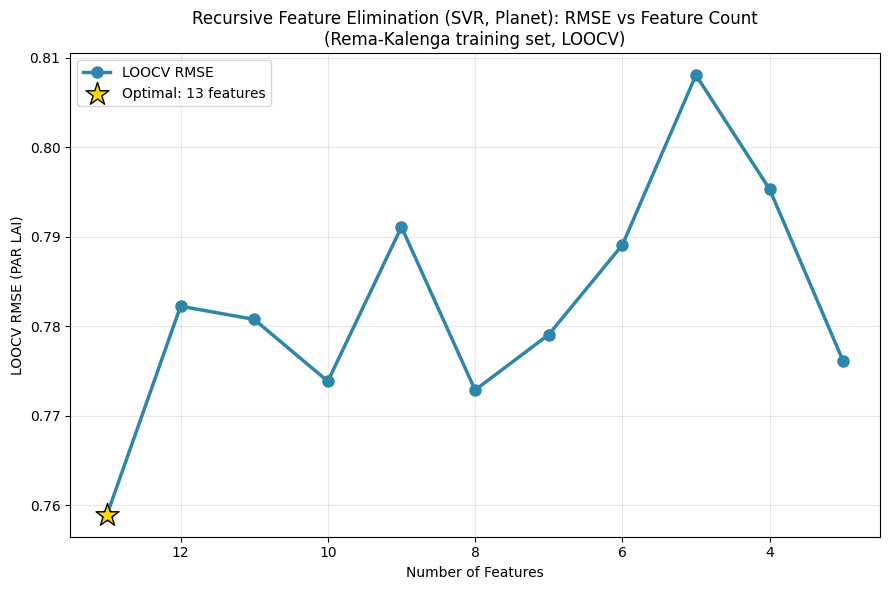

In [15]:
# ============================================================
# RECURSIVE FEATURE ELIMINATION (RFE) — SVR
# ============================================================
min_features = 3
elimination_step = 1
absolute_drop_threshold = 0.15
 
current_features_svr = feature_cols.copy()
rfe_results_svr = []
iteration = 0
 
print('\n' + '='*60)
print('STARTING RFE — SVR (Rema-Kalenga Planet training set, LOOCV)')
print('='*60)
 
start_time = time.time()
 
while True:
    iteration += 1
    n_current = len(current_features_svr)
 
    scaler_iter = StandardScaler()
    X_train_iter_scaled = scaler_iter.fit_transform(X_train_rema[current_features_svr])
 
    svr_eval = SVR(**best_params_svr)
    scores = cross_val_score(
        svr_eval,
        X_train_iter_scaled,
        y_train_rema,
        cv=loo,
        scoring='neg_mean_squared_error'
    )
    rmse = np.sqrt(-scores.mean())
 
    if len(rfe_results_svr) == 0:
        baseline_rmse = rmse
        rmse_increase = 0.0
    else:
        baseline_rmse = rfe_results_svr[0]['rmse']
        rmse_increase = rmse - baseline_rmse
 
    print(f'\nIteration {iteration}: {n_current} features -> LOOCV RMSE = {rmse:.3f} '
          f'(change from baseline: {rmse_increase:+.3f})')
 
    rfe_results_svr.append({
        'iteration': iteration,
        'n_features': n_current,
        'features': current_features_svr.copy(),
        'rmse': rmse,
        'rmse_increase': rmse_increase
    })
 
    should_stop = False
    if len(rfe_results_svr) > 1 and rmse_increase > absolute_drop_threshold:
        should_stop = True
        print(f'  STOPPING: RMSE rose by {rmse_increase:.3f} (threshold: {absolute_drop_threshold})')
    if n_current <= min_features:
        should_stop = True
        print(f'  STOPPING: reached minimum feature count ({min_features})')
 
    if should_stop:
        break
 
    svr_importance = SVR(**best_params_svr)
    svr_importance.fit(X_train_iter_scaled, y_train_rema)
 
    perm_result = permutation_importance(
        svr_importance, X_train_iter_scaled, y_train_rema,
        n_repeats=30, random_state=42, scoring='neg_mean_squared_error'
    )
    importances = dict(zip(current_features_svr, perm_result.importances_mean))
 
    sorted_feats = sorted(importances.items(), key=lambda x: x[1])
    n_to_remove = min(elimination_step, len(current_features_svr) - min_features)
    features_to_remove = [f for f, _ in sorted_feats[:n_to_remove]]
    print(f'  Removing: {features_to_remove}')
 
    current_features_svr = [f for f in current_features_svr if f not in features_to_remove]
 
total_time = time.time() - start_time
 
best_rfe_svr = min(rfe_results_svr, key=lambda x: x['rmse'])
rfe_selected_features_svr = best_rfe_svr['features']
 
print('\n' + '='*60)
print('RFE COMPLETE — SVR')
print('='*60)
print(f'Total time: {total_time/60:.1f} min')
print(f'Optimal feature count: {best_rfe_svr["n_features"]}')
print(f'Optimal features: {rfe_selected_features_svr}')
print(f'Optimal LOOCV RMSE: {best_rfe_svr["rmse"]:.3f} (baseline was {rfe_results_svr[0]["rmse"]:.3f})')
 
rfe_df_svr = pd.DataFrame(rfe_results_svr)
 
plt.figure(figsize=(9, 6))
plt.plot(rfe_df_svr['n_features'], rfe_df_svr['rmse'], marker='o', markersize=8,
         linewidth=2.5, color='#2E86AB', label='LOOCV RMSE')
 
best_idx_svr = rfe_df_svr['rmse'].idxmin()
plt.scatter(rfe_df_svr.loc[best_idx_svr, 'n_features'], rfe_df_svr.loc[best_idx_svr, 'rmse'],
            color='gold', s=300, marker='*', zorder=5, edgecolor='black',
            label=f'Optimal: {rfe_df_svr.loc[best_idx_svr, "n_features"]} features')
 
plt.xlabel('Number of Features')
plt.ylabel('LOOCV RMSE (PAR LAI)')
plt.title('Recursive Feature Elimination (SVR, Planet): RMSE vs Feature Count\n(Rema-Kalenga training set, LOOCV)')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Rema-Kalenga SVR model performance summary (Planet, RFE-selected features) ===
                                                      Set  N    R2  RMSE   MAE  rRMSE (%)  Bias (mean residual)
Rema-Kalenga Train (in-sample, SVR, Planet, RFE features) 47 0.594 0.561 0.437       25.9                -0.009
  Rema-Kalenga Test (held-out, SVR, Planet, RFE features) 12 0.301 0.749 0.581       34.6                 0.002

Selected kernel is non-linear (rbf) — SVR has no native feature importance.
(Permutation importance was used internally to drive RFE elimination.)

=== Per-plot residuals (Rema-Kalenga test set, SVR, Planet, RFE features) ===
 cluster_id  observed_par_lai  predicted_par_lai  residual
          5          0.331170              2.061     1.730
          4          2.068093              2.014    -0.054
         42          1.949388              1.897    -0.052
         14          1.625104              2.105     0.480
         56          3.173609              2.281    -0.893


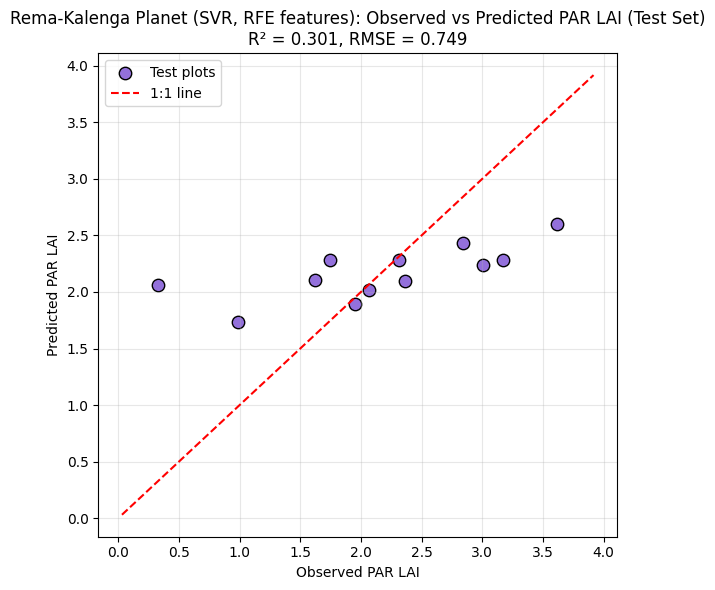

In [16]:
# ============================================================
# REFIT FINAL MODEL ON RFE-SELECTED FEATURES — THIS IS THE MODEL USED FOR TRANSFER
# A fresh scaler is fit on the RFE-selected columns only (train set), and
# reused (never refit) for the test set and the KNP transfer target.
# ============================================================
scaler = StandardScaler()
X_train_rema_final_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_rema[rfe_selected_features_svr]),
    columns=rfe_selected_features_svr, index=X_train_rema.index
)
X_test_rema_final_scaled = pd.DataFrame(
    scaler.transform(X_test_rema[rfe_selected_features_svr]),
    columns=rfe_selected_features_svr, index=X_test_rema.index
)
 
final_svr_rema = SVR(**best_params_svr)
final_svr_rema.fit(X_train_rema_final_scaled, y_train_rema)
 
y_pred_train_rema_svr = final_svr_rema.predict(X_train_rema_final_scaled)
y_pred_test_rema_svr = final_svr_rema.predict(X_test_rema_final_scaled)
 
metrics_train_rema_svr = compute_metrics(y_train_rema, y_pred_train_rema_svr, 'Rema-Kalenga Train (in-sample, SVR, Planet, RFE features)')
metrics_test_rema_svr = compute_metrics(y_test_rema, y_pred_test_rema_svr, 'Rema-Kalenga Test (held-out, SVR, Planet, RFE features)')
 
metrics_df_rema_svr = pd.DataFrame([metrics_train_rema_svr, metrics_test_rema_svr])
print('=== Rema-Kalenga SVR model performance summary (Planet, RFE-selected features) ===')
print(metrics_df_rema_svr.to_string(index=False))
print()
 
if best_params_svr['kernel'] == 'linear':
    importance_df_rema_svr = pd.DataFrame({
        'Feature': rfe_selected_features_svr,
        'Abs_Coefficient': np.abs(final_svr_rema.coef_[0])
    }).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)
    print('=== Feature importance proxy (|coefficient|, linear kernel only, RFE features) ===')
    print(importance_df_rema_svr.to_string(index=False))
else:
    print('Selected kernel is non-linear (rbf) — SVR has no native feature importance.')
    print('(Permutation importance was used internally to drive RFE elimination.)')
print()
 
residuals_df_rema_svr = pd.DataFrame({
    'cluster_id': df_rema.loc[X_test_rema.index, 'cluster_id'].values,
    'observed_par_lai': y_test_rema.values,
    'predicted_par_lai': y_pred_test_rema_svr.round(3),
    'residual': (y_pred_test_rema_svr - y_test_rema.values).round(3)
})
print('=== Per-plot residuals (Rema-Kalenga test set, SVR, Planet, RFE features) ===')
print(residuals_df_rema_svr.to_string(index=False))
print()
 
plt.figure(figsize=(6, 6))
plt.scatter(y_test_rema, y_pred_test_rema_svr, color='mediumpurple', edgecolor='black', s=80, label='Test plots')
lims = [min(y_test_rema.min(), y_pred_test_rema_svr.min()) - 0.3,
        max(y_test_rema.max(), y_pred_test_rema_svr.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('Observed PAR LAI')
plt.ylabel('Predicted PAR LAI')
plt.title(f'Rema-Kalenga Planet (SVR, RFE features): Observed vs Predicted PAR LAI (Test Set)\n'
          f'R² = {metrics_test_rema_svr["R2"]}, RMSE = {metrics_test_rema_svr["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Spatial Transfer Performance (Rema-Kalenga SVR -> KNP, Planet, RFE features) ===
                                                                   Set  N     R2  RMSE   MAE  rRMSE (%)  Bias (mean residual)
Spatial Transfer: Rema-Kalenga SVR model (Planet, RFE features) -> KNP 40 -0.049 1.238 1.003       50.7                -0.168

=== Per-plot residuals (KNP, spatial transfer, SVR, Planet, RFE features) ===
cluster_id  observed_par_lai  predicted_par_lai  residual
        20             1.671              2.285     0.615
         2             3.039              2.217    -0.822
        27             2.155              2.190     0.035
        40             0.285              2.208     1.922
        11             3.924              2.247    -1.677
        13             3.148              2.289    -0.859
        25             4.924              2.193    -2.731
        32             1.538              2.222     0.684
        33             3.216              2.211    -1.005
    

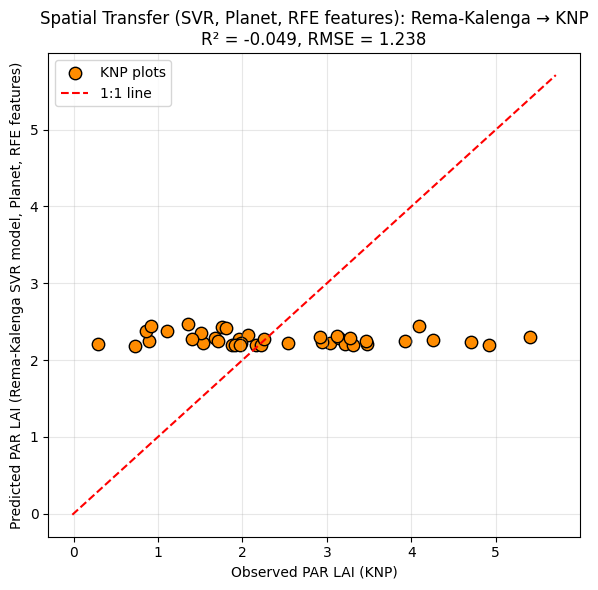

In [ ]:
# ============================================================
# APPLY FROZEN SVR MODEL TO KNP (NO RETRAINING) — RFE-SELECTED FEATURES ONLY
# IMPORTANT: use the SAME scaler fit on Rema-Kalenga training data (RFE
# features) — never refit the scaler on KNP data, or this stops being a true
# naive transfer test.
# ============================================================
X_knp = df_knp[rfe_selected_features_svr]
X_knp_scaled = pd.DataFrame(
    scaler.transform(X_knp), columns=rfe_selected_features_svr, index=X_knp.index
)
y_knp_true = df_knp['par_lai']
 
y_knp_pred_svr = final_svr_rema.predict(X_knp_scaled)
 
metrics_transfer_knp_svr = compute_metrics(
    y_knp_true, y_knp_pred_svr, 'Spatial Transfer: Rema-Kalenga SVR model (Planet, RFE features) -> KNP'
)
transfer_metrics_df_knp_svr = pd.DataFrame([metrics_transfer_knp_svr])
 
print('=== Spatial Transfer Performance (Rema-Kalenga SVR -> KNP, Planet, RFE features) ===')
print(transfer_metrics_df_knp_svr.to_string(index=False))
print()
 
transfer_residuals_df_knp_svr = pd.DataFrame({
    'cluster_id': df_knp['cluster_id'],
    'observed_par_lai': y_knp_true.round(3),
    'predicted_par_lai': y_knp_pred_svr.round(3),
    'residual': (y_knp_pred_svr - y_knp_true).round(3)
})
print('=== Per-plot residuals (KNP, spatial transfer, SVR, Planet, RFE features) ===')
print(transfer_residuals_df_knp_svr.to_string(index=False))
print()
 
plt.figure(figsize=(6, 6))
plt.scatter(y_knp_true, y_knp_pred_svr, color='darkorange', edgecolor='black', s=80, label='KNP plots')
lims = [min(y_knp_true.min(), y_knp_pred_svr.min()) - 0.3,
        max(y_knp_true.max(), y_knp_pred_svr.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')s
plt.xlabel('Observed PAR LAI (KNP)')
plt.ylabel('Predicted PAR LAI (Rema-Kalenga SVR model, Planet, RFE features)')
plt.title(f'Spatial Transfer (SVR, Planet, RFE features): Rema-Kalenga → KNP\n'
          f'R² = {metrics_transfer_knp_svr["R2"]}, RMSE = {metrics_transfer_knp_svr["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()